# Chapter 2 Exercises

## Preparation

In [ ]:
import os
import sys
sys.path.append(os.path.abspath(os.path.join('..')))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils.data_paths import IVE_TICKS
from utils.sampling_bars import dollar_bar, dollar_imbalance_bar

df = pd.read_parquet(IVE_TICKS)

## 2. On a series of E-mini S&P 500 futures tick data, compute dollar bars and dollar imbalance bars. What bar type exhibits greater serial correlation? Why?

In [3]:
dollar_bars = dollar_bar(df)

In [4]:
dollar_imbalance_bars = dollar_imbalance_bar(df, expected_num_ticks_init=100)
dollar_imbalance_bars.shape

(727, 5)

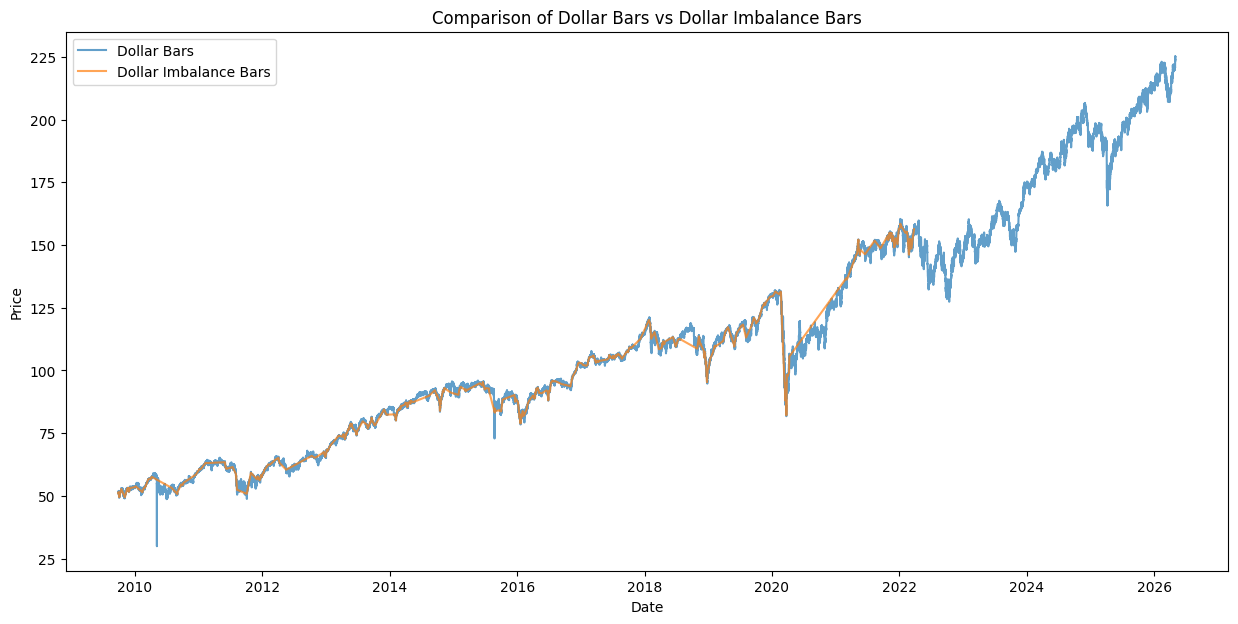

In [6]:
# Compare the bar types by plotting their prices over time in the same figure (x-axis: date)
plt.figure(figsize=(15, 7))
plt.plot(dollar_bars.index, dollar_bars['price'], label='Dollar Bars', alpha=0.7)
plt.plot(dollar_imbalance_bars.index, dollar_imbalance_bars['price'], label='Dollar Imbalance Bars', alpha=0.7)
plt.xlabel('Date')
plt.ylabel('Price')
plt.title('Comparison of Dollar Bars vs Dollar Imbalance Bars')
plt.legend()
plt.show()

In [8]:
# Get the serial correlation of the two bar types
dollar_bars['log_return'] = np.log(dollar_bars['price'] / dollar_bars['price'].shift(1))
dollar_imbalance_bars['log_return'] = np.log(dollar_imbalance_bars['price'] / dollar_imbalance_bars['price'].shift(1))

# Compute the serial correlation of returns for the two bar types
dollar_bars['serial_correlation_log_return'] = dollar_bars['log_return'].autocorr()
dollar_imbalance_bars['serial_correlation_log_return'] = dollar_imbalance_bars['log_return'].autocorr()

# Print the serial correlation of returns for the two bar types
print(f"Dollar bars log return serial correlation: {dollar_bars['serial_correlation_log_return'].mean()}")
print(f"Dollar imbalance bars log return serial correlation: {dollar_imbalance_bars['serial_correlation_log_return'].mean()}")

Dollar bars log return serial correlation: 0.04411945839244384
Dollar imbalance bars log return serial correlation: 0.012040541282202276
